In [1]:
# EXPERIMENTO 3 (OBSERVACIONAL): barrido de beta sobre los 11 datasets sinteticos del benchmark.
# Mismo protocolo que el Experimento 1, pero cambiando el SCM triangulo hecho a mano por los datasets
# de src/datasets/synthetic.py (la misma lista que usa notebooks/alejandro/paper_plots.ipynb).
import os
import sys

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..", "..", "..")))

import time
import numpy as np
import pandas as pd
import networkx as nx
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from src.utils.metrics import mmd, rf
from src.models.kan import kan_model_mixed
from src.datasets.synthetic import graph_data


# --- [PASO 1: FUNCIONES AUXILIARES] ---

def crear_estructura_nodos(grafo, params_base, loss_name, alpha, beta, node_types, num_classes):
    """Empaqueta la configuracion de pesos por nodo requerida por kan_model_mixed."""
    config_nodos = {}
    for nodo in grafo.nodes():
        nodo_params = params_base.copy()
        nodo_params['loss'] = loss_name
        nodo_params['alpha_weight'] = alpha
        nodo_params['beta_weight'] = beta
        nodo_params['node_types'] = node_types
        nodo_params['num_classes'] = num_classes
        config_nodos[nodo] = nodo_params
    return config_nodos

def preparar_residuo(res):
    """Convierte tensores de Torch o arrays a numpy array plano de forma segura."""
    if hasattr(res, 'detach'): res = res.detach()
    if hasattr(res, 'cpu'): res = res.cpu()
    return np.array(res).flatten()


# --- [PASO 2: CONFIGURACION DEL EXPERIMENTO] ---

# Los 11 datasets del benchmark continuo del paper (misma lista que paper_plots.ipynb).
datasets_evaluados = ['3-chain-linear', '3-chain-non-linear', '4-chain-linear', '5-chain-linear',
                      'collider-linear', 'fork-linear', 'fork-non-linear', 'simpson-non-linear',
                      'simpson-symprod', 'triangle-linear', 'triangle-non-linear']

# N_actual es el tamano del conjunto de ENTRENAMIENTO; la evaluacion siempre usa 100 muestras fijas.
valores_N_experimento = [50, 100]
valores_beta_candidatos = [0.0, 0.3, 0.6]
semillas_experimento = np.arange(42, 52)  # 10 semillas (42-51)

# Conjunto de evaluacion FIJO por dataset: todas las semillas, N y betas se evaluan siempre contra las
# mismas 100 muestras, generadas una unica vez con una semilla propia fuera de semillas_experimento.
N_EVAL_FIJO = 100
SEED_EVAL_FIJO = 9999

# Metricas observacionales de este experimento.
metricas_experimento = ['RF Acc', 'MMD', 'MAE x3']

base_kan_params = {
    'hidden_dim': 5, 'batch_size': -1, 'grid': 5, 'k': 5, 'seed': 42,
    'lr': 0.002, 'early_stop': True, 'steps': 5000, 'lamb': 0.05,
    'lamb_entropy': 0.05, 'sparse_init': False, 'mult_kan': True,
    'try_gpu': False, 'verbose': 0
}

registros_tabla_final = []
t_inicio_global = time.time()
total_runs = len(datasets_evaluados) * len(semillas_experimento) * len(valores_N_experimento) * len(valores_beta_candidatos)
print(f"Runs previstos: {total_runs} "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas x {len(valores_N_experimento)} N x {len(valores_beta_candidatos)} betas)")


# --- [PASO 3: BUCLE PRINCIPAL DE ENTRENAMIENTO Y EVALUACION] ---

for dataset in datasets_evaluados:
    print("\n" + "#"*70)
    print(f"DATASET: {dataset}")
    print("#"*70)

    # graph_data(...).generate devuelve (data, data_cf, graph, formula); aqui solo se usan data y graph.
    factual_eval_d, _, graph_ds, _ = graph_data(name=dataset).generate(num_samples=N_EVAL_FIJO, seed=SEED_EVAL_FIJO)
    # El orden de graph_ds.nodes NO coincide con el de las columnas en collider/fork: usar var_names.
    var_names = list(factual_eval_d.columns)
    datos_reales_test = factual_eval_d[var_names].to_numpy()
    num_muestras_eval = len(factual_eval_d)

    node_types = {nodo: 'continuous' for nodo in graph_ds.nodes}
    num_classes = {}

    print(f"  Nodos: {var_names} | Aristas: {list(graph_ds.edges)}")

    for experiment_id, seed in enumerate(semillas_experimento, start=1):
        for N_actual in valores_N_experimento:
            factual_train_d, _, _, _ = graph_data(name=dataset).generate(num_samples=N_actual, seed=int(seed))

            for beta_val in valores_beta_candidatos:
                # Misma convencion que el Experimento 1: beta=0 es MSE puro, beta>0 es hibrido con alpha=1-beta.
                if beta_val == 0.0:
                    strategy_name, alpha_val = "mse", 1.0
                else:
                    strategy_name, alpha_val = "hybrid", round(1.0 - beta_val, 2)

                params_estructurados = crear_estructura_nodos(
                    graph_ds, base_kan_params, strategy_name, alpha_val, beta_val, node_types, num_classes
                )

                print(f" -> {dataset} | semilla={seed} | N={N_actual} | beta={beta_val} ({strategy_name.upper()})")
                model = kan_model_mixed(graph_ds, params_estructurados)
                model.fit(data=factual_train_d)

                conf_name = "MSE" if strategy_name == "mse" else f"HYBRID_ALPHA{alpha_val}_BETA{beta_val}"
                fila = {
                    'Dataset': dataset,
                    'Experiment': experiment_id,
                    'Seed': int(seed),
                    'Loss': strategy_name,
                    'Conf': conf_name,
                    'Alpha': alpha_val,
                    'Beta': beta_val,
                    'N': N_actual
                }

                try:
                    # MAE x3: error absoluto medio del residuo de la ecuacion estructural de x3 (analogo al MAE Z del Exp. 1).
                    residuos = model.get_residuals(factual_eval_d)
                    r_x3 = preparar_residuo(residuos['x3'])
                    fila['MAE x3'] = round(float(np.mean(np.abs(r_x3))), 5)

                    datos_gen = model.draw_samples(num_samples=num_muestras_eval)[var_names].to_numpy()
                    fila['MMD'] = round(float(max(0.0, mmd(datos_reales_test, datos_gen))), 5)
                    fila['RF Acc'] = round(float(rf(datos_reales_test, datos_gen)), 5)

                except Exception as e:
                    print(f"   [Error en evaluacion] {dataset} | {conf_name} | N={N_actual} | semilla={seed}: {e}")

                registros_tabla_final.append(fila)


# --- [PASO 4: TABLA MAESTRA] ---
df_final = pd.DataFrame(registros_tabla_final)
base_cols = ['Dataset', 'Experiment', 'Seed', 'Loss', 'Conf', 'Alpha', 'Beta', 'N']
df_final = df_final[base_cols + metricas_experimento]
df_final = df_final.sort_values(by=['Dataset', 'N', 'Beta', 'Seed']).reset_index(drop=True)

print(f"\n--- MATRIZ DE DIAGNOSTICO FINALIZADA ({len(df_final)} runs en {time.time() - t_inicio_global:.0f} s) ---")
display(df_final)

# --- [PASO 5: GUARDADO EN CSV] ---
carpeta_tablas = "tablas"
if not os.path.exists(carpeta_tablas):
    os.makedirs(carpeta_tablas)
ruta_archivo = os.path.join(carpeta_tablas, "datasets_sinteticos_observacional.csv")
df_final.to_csv(ruta_archivo, index=False)
print(f"Tabla maestra guardada en: {ruta_archivo}")


######################################################################
DATASET: 3-chain-linear
######################################################################
  Nodos: ['x1', 'x2', 'x3'] | Aristas: [('x1', 'x2'), ('x2', 'x3')]
 -> 3-chain-linear | semilla=42 | N=100 | beta=0.0 (MSE)
Using device: cpu
Early stopping at step 337
Using device: cpu
Early stopping at step 72
 -> 3-chain-linear | semilla=42 | N=100 | beta=0.3 (HYBRID)
Using device: cpu
Early stopping at step 272
Using device: cpu
Early stopping at step 450
 -> 3-chain-linear | semilla=42 | N=100 | beta=0.6 (HYBRID)
Using device: cpu
Early stopping at step 135
Using device: cpu
Early stopping at step 281
 -> 3-chain-linear | semilla=43 | N=100 | beta=0.0 (MSE)
Using device: cpu
Early stopping at step 180
Using device: cpu
Early stopping at step 37
 -> 3-chain-linear | semilla=43 | N=100 | beta=0.3 (HYBRID)
Using device: cpu
Early stopping at step 206
Using device: cpu
Early stopping at step 37
 -> 3-chain-linear | sem

,Dataset,Experiment,Seed,Loss,Conf,Alpha,Beta,N,RF Acc,MMD,MAE x3
0,3-chain-linear,1,42,mse,MSE,1.0,0.0,100,0.525,0.01692,0.84235
1,3-chain-linear,2,43,mse,MSE,1.0,0.0,100,0.625,0.01514,0.83747
2,3-chain-linear,3,44,mse,MSE,1.0,0.0,100,0.550,0.01042,0.84017
3,3-chain-linear,1,42,hybrid,HYBRID_ALPHA0.7_BETA0.3,0.7,0.3,100,0.625,0.01901,0.89521
4,3-chain-linear,2,43,hybrid,HYBRID_ALPHA0.7_BETA0.3,0.7,0.3,100,0.600,0.01281,0.83702
...,...,...,...,...,...,...,...,...,...,...,...
94,triangle-non-linear,2,43,hybrid,HYBRID_ALPHA0.7_BETA0.3,0.7,0.3,100,0.625,0.01648,0.28702
95,triangle-non-linear,3,44,hybrid,HYBRID_ALPHA0.7_BETA0.3,0.7,0.3,100,0.550,0.01360,0.31579
96,triangle-non-linear,1,42,hybrid,HYBRID_ALPHA0.4_BETA0.6,0.4,0.6,100,0.625,0.01320,0.24114
97,triangle-non-linear,2,43,hybrid,HYBRID_ALPHA0.4_BETA0.6,0.4,0.6,100,0.600,0.01782,0.31457


Tabla maestra guardada en: tablas\datasets_sinteticos_observacional.csv


In [2]:
# PASO 6: resumen media +/- std sobre las 10 semillas, para cada combinacion (Dataset, N, Beta).
print("\n" + "="*100)
print("TABLA RESUMEN: MEDIA +/- DESVIACION TIPICA POR DATASET, N Y BETA")
print("="*100)

resumen_por_dataset = []
for (dataset, n_val, beta_val), grupo in df_final.groupby(['Dataset', 'N', 'Beta']):
    fila_resumen = {
        'Dataset': dataset,
        'N': n_val,
        'Beta': beta_val,
        'Alpha': grupo['Alpha'].iloc[0],
        'Loss': grupo['Loss'].iloc[0],
        'Num_Seeds': len(grupo)
    }
    for metrica in metricas_experimento:
        fila_resumen[f'{metrica}_mean'] = round(float(grupo[metrica].mean()), 5)
        fila_resumen[f'{metrica}_std'] = round(float(grupo[metrica].std()), 5)
    resumen_por_dataset.append(fila_resumen)

df_resumen = pd.DataFrame(resumen_por_dataset).sort_values(['Dataset', 'N', 'Beta']).reset_index(drop=True)
display(df_resumen)

ruta_resumen = os.path.join("tablas", "resumen_por_dataset_observacional.csv")
df_resumen.to_csv(ruta_resumen, index=False)
print(f"\nTabla resumen guardada en: {ruta_resumen}")

# Version legible "media +/- std", un bloque por (dataset, N).
print(f"\n\n{'='*100}")
print("FORMATO LEGIBLE: Media +/- Std por dataset y N")
print(f"{'='*100}")
for dataset in datasets_evaluados:
    for n_val in valores_N_experimento:
        df_ds = df_resumen[(df_resumen['Dataset'] == dataset) & (df_resumen['N'] == n_val)]
        if df_ds.empty:
            continue
        tabla_legible = {}
        for _, r in df_ds.iterrows():
            tabla_legible[f"Beta={r['Beta']}"] = [f"{r[f'{m}_mean']:.5f} +/- {r[f'{m}_std']:.5f}" for m in metricas_experimento]
        print(f"\n{'-'*100}\n{dataset}  |  N = {n_val}\n{'-'*100}")
        display(pd.DataFrame(tabla_legible, index=metricas_experimento))


TABLA RESUMEN: MEDIA +/- DESVIACION TIPICA POR DATASET Y BETA (3 SEMILLAS)


,Dataset,Beta,Alpha,Loss,Num_Seeds,RF Acc_mean,RF Acc_std,MMD_mean,MMD_std,MAE x3_mean,MAE x3_std
0,3-chain-linear,0.0,1.0,mse,3,0.56667,0.05204,0.01416,0.00336,0.84000,0.00244
1,3-chain-linear,0.3,0.7,hybrid,3,0.59167,0.03819,0.01392,0.00464,0.85432,0.03555
2,3-chain-linear,0.6,0.4,hybrid,3,0.61667,0.02887,0.01229,0.00308,0.84100,0.01428
3,3-chain-non-linear,0.0,1.0,mse,3,0.56667,0.01443,0.01013,0.00277,0.24587,0.03096
4,3-chain-non-linear,0.3,0.7,hybrid,3,0.63333,0.07638,0.00925,0.00179,0.24839,0.03248
5,3-chain-non-linear,0.6,0.4,hybrid,3,0.59167,0.08036,0.01001,0.00439,0.24798,0.02437
6,4-chain-linear,0.0,1.0,mse,3,0.57500,0.02500,0.01255,0.00331,0.81698,0.03687
7,4-chain-linear,0.3,0.7,hybrid,3,0.56667,0.03819,0.01068,0.00273,0.81469,0.03106
8,4-chain-linear,0.6,0.4,hybrid,3,0.57500,0.05000,0.01011,0.00283,0.81238,0.02610
9,5-chain-linear,0.0,1.0,mse,3,0.55833,0.03819,0.01335,0.00162,0.84000,0.00244



Tabla resumen guardada en: tablas\resumen_por_dataset_observacional.csv


FORMATO LEGIBLE: Media +/- Std por dataset

----------------------------------------------------------------------------------------------------
3-chain-linear
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.56667 +/- 0.05204,0.59167 +/- 0.03819,0.61667 +/- 0.02887
MMD,0.01416 +/- 0.00336,0.01392 +/- 0.00464,0.01229 +/- 0.00308
MAE x3,0.84000 +/- 0.00244,0.85432 +/- 0.03555,0.84100 +/- 0.01428



----------------------------------------------------------------------------------------------------
3-chain-non-linear
----------------------------------------------------------------------------------------------------


...

,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.54167 +/- 0.03819,0.57500 +/- 0.07500,0.58333 +/- 0.07638
MMD,0.01602 +/- 0.00438,0.01592 +/- 0.00729,0.01586 +/- 0.00703
MAE x3,0.73231 +/- 0.04987,0.71768 +/- 0.05175,0.72947 +/- 0.02929



----------------------------------------------------------------------------------------------------
triangle-linear
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.61667 +/- 0.05774,0.61667 +/- 0.05774,0.60833 +/- 0.07217
MMD,0.01319 +/- 0.00473,0.01236 +/- 0.00283,0.01267 +/- 0.00340
MAE x3,0.90377 +/- 0.26786,1.81198 +/- 2.21407,0.61791 +/- 0.11284



----------------------------------------------------------------------------------------------------
triangle-non-linear
----------------------------------------------------------------------------------------------------


,Beta=0.0,Beta=0.3,Beta=0.6
RF Acc,0.64167 +/- 0.08780,0.59167 +/- 0.03819,0.60833 +/- 0.01443
MMD,0.01668 +/- 0.00170,0.01531 +/- 0.00151,0.01505 +/- 0.00245
MAE x3,0.27764 +/- 0.01039,0.29100 +/- 0.02306,0.30647 +/- 0.06168



VISUALIZACION: MEDIA Y DESVIACION TIPICA POR METRICA
(Linea = Media sobre las 3 semillas | Area sombreada = Media +/- Std | Un color = un dataset)

Grafica guardada: plots\bandplot_datasets_observacional.png



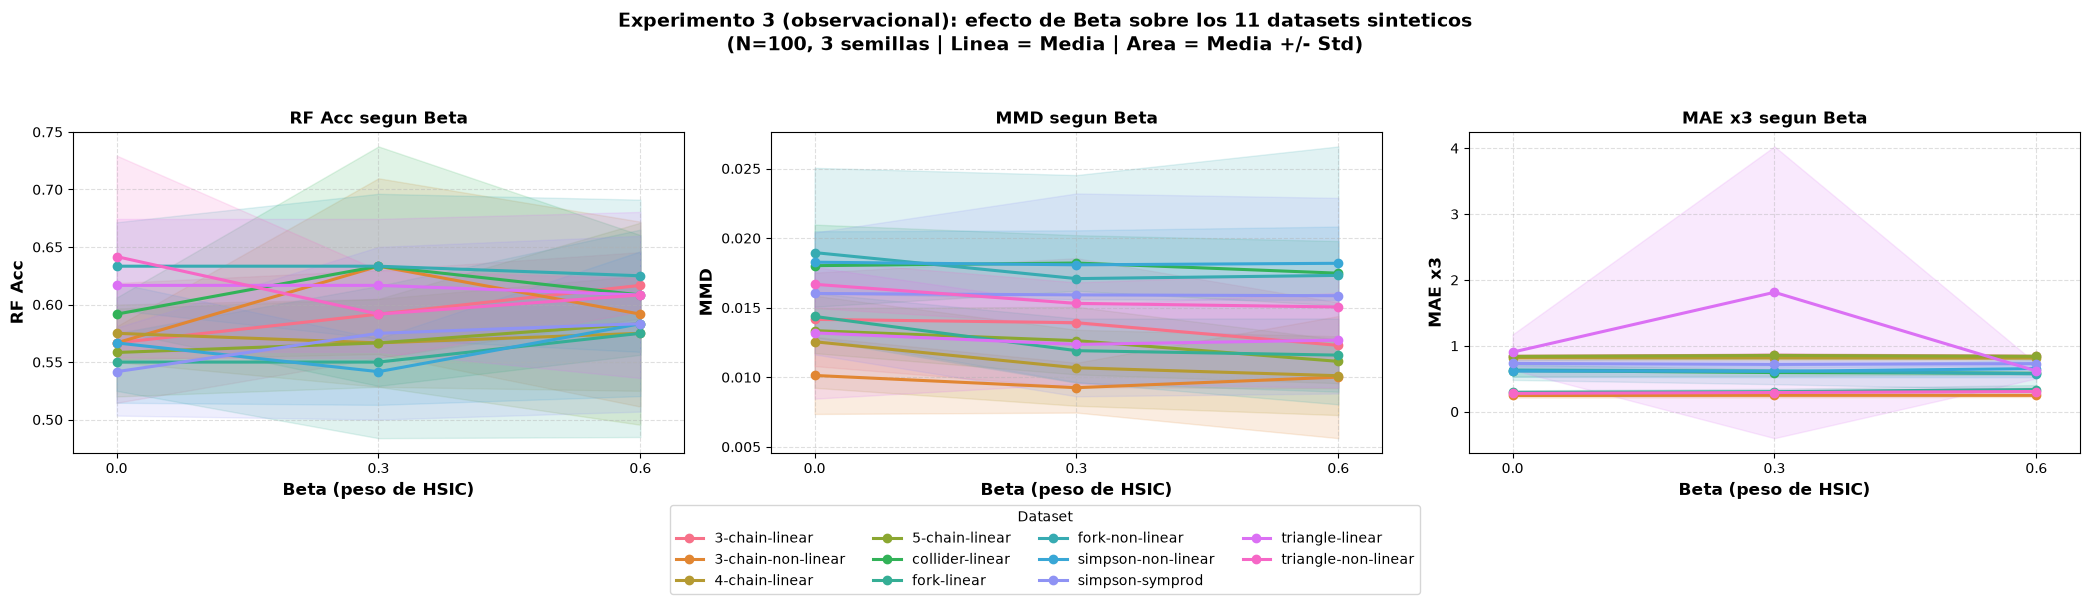

In [3]:
# PASO 7: una grafica por metrica (RF Acc, MMD, MAE x3). Eje X = beta, una curva por dataset,
# linea = media sobre las 10 semillas y banda sombreada = media +/- desviacion tipica.
# Una figura por cada N: mezclar los dos N en el mismo panel daria 22 curvas ilegibles.
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION: MEDIA Y DESVIACION TIPICA POR METRICA")
print("(Linea = Media sobre las 10 semillas | Area sombreada = Media +/- Std | Un color = un dataset)")
print("(Una figura por cada N)")
print("="*100 + "\n")

colores_ds = sns.color_palette("husl", len(datasets_evaluados))
paleta_ds = dict(zip(datasets_evaluados, colores_ds))

if not os.path.exists('plots'):
    os.makedirs('plots')

for n_val in valores_N_experimento:
    df_n = df_resumen[df_resumen['N'] == n_val]
    if df_n.empty:
        continue

    # Las 3 metricas se apilan en vertical: una fila por metrica.
    fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
    fig.suptitle('Experimento 3 (observacional): efecto de Beta sobre los 11 datasets sinteticos\n'
                 f'(N={n_val}, {len(semillas_experimento)} semillas | Linea = Media | Area = Media +/- Std)',
                 fontsize=14, fontweight='bold')

    for ax, metrica in zip(axes, metricas_experimento):
        for dataset in datasets_evaluados:
            df_ds = df_n[df_n['Dataset'] == dataset].sort_values('Beta')
            x = df_ds['Beta'].values
            y_mean = df_ds[f'{metrica}_mean'].values
            y_std = np.nan_to_num(df_ds[f'{metrica}_std'].values)

            ax.plot(x, y_mean, marker='o', linewidth=2.2, markersize=6, color=paleta_ds[dataset], label=dataset)
            ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=paleta_ds[dataset])

        ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
        ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
        ax.set_title(f'{metrica} segun Beta  -  N = {n_val}', fontsize=12, fontweight='bold')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.set_xticks(valores_beta_candidatos)
        ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)

    # Una unica leyenda compartida para los 11 datasets, debajo de la figura.
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', ncol=3, fontsize=10, frameon=True, title='Dataset')
    plt.tight_layout(rect=[0, 0.06, 1, 0.96])

    ruta_plot = os.path.join('plots', f'bandplot_datasets_observacional_n_{n_val}.png')
    plt.savefig(ruta_plot, dpi=300, bbox_inches='tight')
    print(f"Grafica guardada: {ruta_plot}\n")
    plt.show()

In [4]:
# PASO 8: tabla final por (N, beta). Filas = las 3 metricas, columnas = mean y std, agregando los
# 11 datasets x 10 semillas (110 runs por celda). Es la tabla que se comparara contra otros modelos.
print("\n" + "="*100)
print(f"TABLA FINAL: MEDIA Y DESVIACION TIPICA POR N Y BETA "
      f"({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas)")
print("="*100)

registros_finales = []
for n_val in valores_N_experimento:
    for beta_val in valores_beta_candidatos:
        df_beta = df_final[(df_final['N'] == n_val) & (np.isclose(df_final['Beta'], beta_val))]
        if df_beta.empty:
            continue
        tabla_beta = pd.DataFrame(
            {'mean': [df_beta[m].mean() for m in metricas_experimento],
             'std': [df_beta[m].std() for m in metricas_experimento]},
            index=metricas_experimento
        ).round(5)

        print(f"\n{'-'*60}\nN = {n_val}  |  Beta = {beta_val}  (Alpha = {round(1.0 - beta_val, 2)}, n_runs = {len(df_beta)})\n{'-'*60}")
        display(tabla_beta)

        for metrica in metricas_experimento:
            registros_finales.append({
                'N': n_val,
                'Beta': beta_val,
                'Metrica': metrica,
                'mean': round(float(df_beta[metrica].mean()), 5),
                'std': round(float(df_beta[metrica].std()), 5)
            })

df_final_resumen = pd.DataFrame(registros_finales)

# Vista compacta: una fila por metrica, una columna por (N, beta), en formato "media +/- std".
print(f"\n\n{'='*100}")
print("VISTA COMPACTA: filas = metricas, columnas = (N, Beta)")
print(f"{'='*100}\n")
tabla_compacta = {}
for n_val in valores_N_experimento:
    for beta_val in valores_beta_candidatos:
        sub = df_final_resumen[(df_final_resumen['N'] == n_val) & (df_final_resumen['Beta'] == beta_val)]
        if sub.empty:
            continue
        col = []
        for metrica in metricas_experimento:
            r = sub[sub['Metrica'] == metrica].iloc[0]
            col.append(f"{r['mean']:.5f} +/- {r['std']:.5f}")
        tabla_compacta[f"N={n_val}, Beta={beta_val}"] = col
display(pd.DataFrame(tabla_compacta, index=metricas_experimento))

ruta_final = os.path.join("tablas", "resumen_final_por_beta_observacional.csv")
df_final_resumen.to_csv(ruta_final, index=False)
print(f"\nTabla final guardada en: {ruta_final}")


TABLA FINAL: MEDIA Y DESVIACION TIPICA POR BETA (11 datasets x 3 semillas)

------------------------------------------------------------
Beta = 0.0  (Alpha = 1.0, n_runs = 33)
------------------------------------------------------------


,mean,std
RF Acc,0.58258,0.04980
MMD,0.01506,0.00391
MAE x3,0.62036,0.25062



------------------------------------------------------------
Beta = 0.3  (Alpha = 0.7, n_runs = 33)
------------------------------------------------------------


,mean,std
RF Acc,0.59091,0.06021
MMD,0.01412,0.00440
MAE x3,0.70183,0.69549



------------------------------------------------------------
Beta = 0.6  (Alpha = 0.4, n_runs = 33)
------------------------------------------------------------


,mean,std
RF Acc,0.59621,0.05732
MMD,0.01379,0.00470
MAE x3,0.59511,0.22222



Tabla final guardada en: tablas\resumen_final_por_beta_observacional.csv



VISUALIZACION DE LA TABLA FINAL: MEDIA +/- STD AGREGADA POR BETA
(Linea = Media | Area sombreada = Media +/- Std | un panel por metrica)

Grafica guardada: plots\bandplot_resumen_final_por_beta_observacional.png



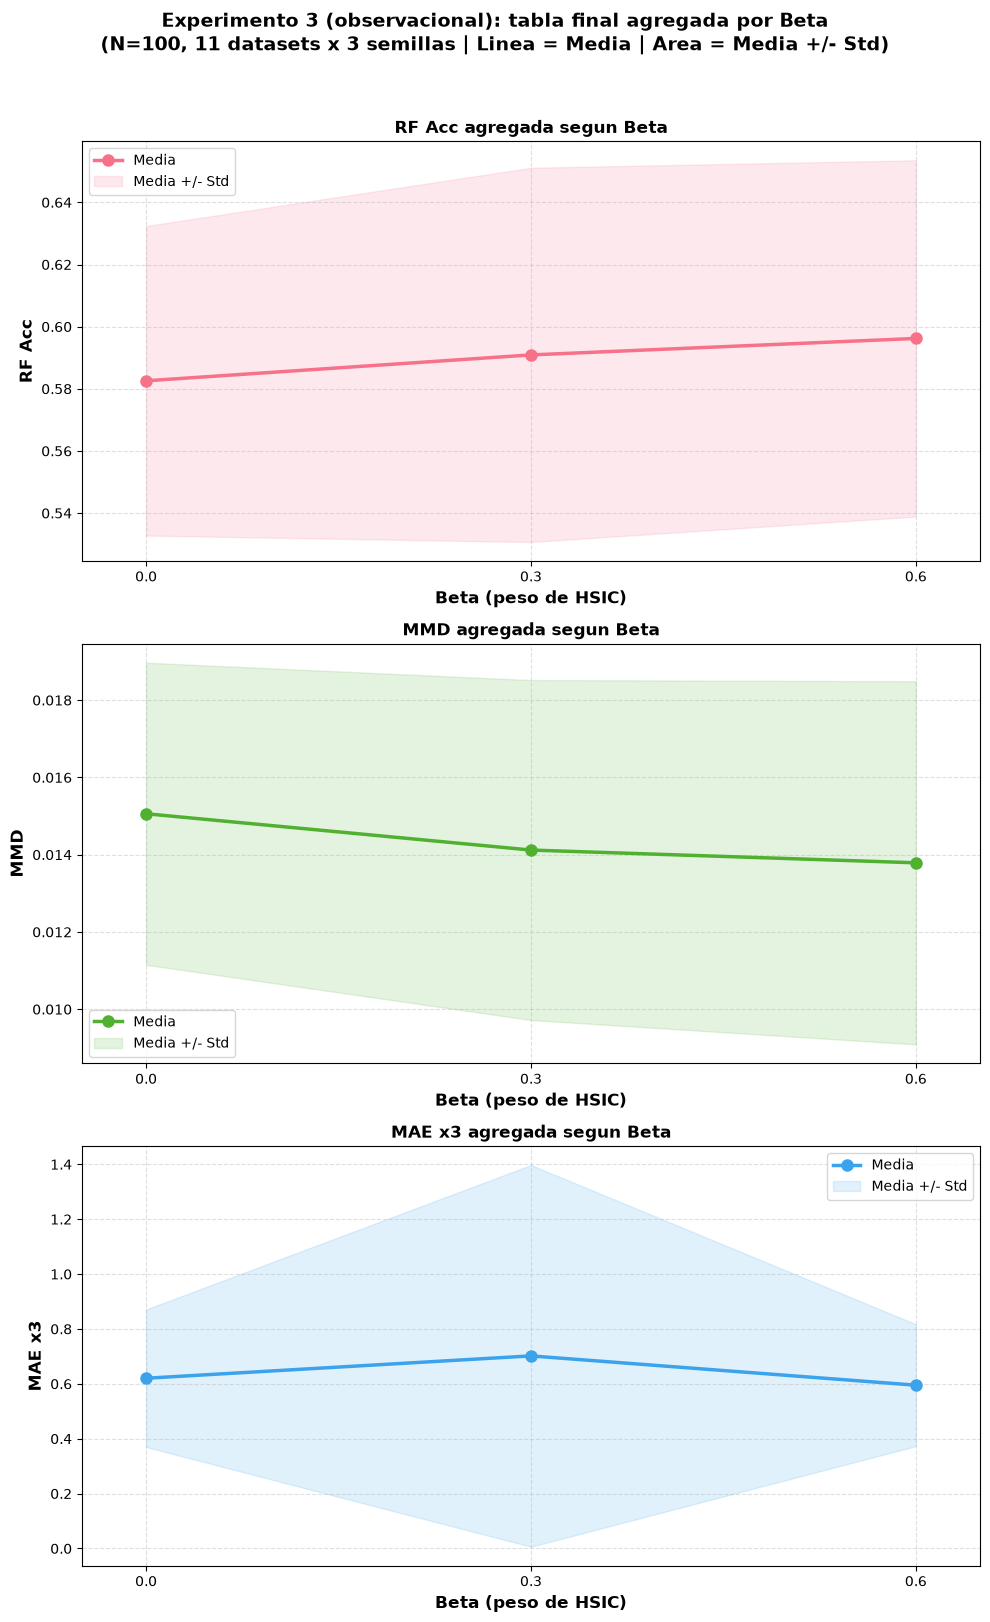

In [6]:
# PASO 9: la tabla final del PASO 8 en forma de grafica. Eje X = beta, una curva por N,
# linea = media agregada sobre los 11 datasets x 10 semillas y banda = media +/- desviacion tipica.
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*100)
print("VISUALIZACION DE LA TABLA FINAL: MEDIA +/- STD AGREGADA POR BETA")
print("(Linea = Media | Area sombreada = Media +/- Std | Un color = un N | un panel por metrica)")
print("="*100 + "\n")

colores_n = dict(zip(valores_N_experimento, sns.color_palette("husl", len(valores_N_experimento))))

# Las 3 metricas se apilan en vertical: una fila por metrica.
fig, axes = plt.subplots(len(metricas_experimento), 1, figsize=(10, 5.5 * len(metricas_experimento)))
fig.suptitle('Experimento 3 (observacional): tabla final agregada por Beta y N\n'
             f'({len(datasets_evaluados)} datasets x {len(semillas_experimento)} semillas | Linea = Media | Area = Media +/- Std)',
             fontsize=14, fontweight='bold')

for ax, metrica in zip(axes, metricas_experimento):
    for n_val in valores_N_experimento:
        df_m = df_final_resumen[(df_final_resumen['Metrica'] == metrica) & (df_final_resumen['N'] == n_val)].sort_values('Beta')
        if df_m.empty:
            continue
        x = df_m['Beta'].values
        y_mean = df_m['mean'].values
        y_std = np.nan_to_num(df_m['std'].values)
        color = colores_n[n_val]

        ax.plot(x, y_mean, marker='o', linewidth=2.5, markersize=8, color=color, label=f'N = {n_val}')
        ax.fill_between(x, y_mean - y_std, y_mean + y_std, alpha=0.15, color=color)

    ax.set_xlabel('Beta (peso de HSIC)', fontsize=12, fontweight='bold')
    ax.set_ylabel(metrica, fontsize=12, fontweight='bold')
    ax.set_title(f'{metrica} agregada segun Beta', fontsize=12, fontweight='bold')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.set_xticks(valores_beta_candidatos)
    ax.set_xlim(min(valores_beta_candidatos) - 0.05, max(valores_beta_candidatos) + 0.05)
    ax.legend(loc='best', fontsize=10, title='N (linea = media, area = +/- std)')

plt.tight_layout(rect=[0, 0, 1, 0.96])

if not os.path.exists('plots'):
    os.makedirs('plots')
ruta_plot_final = os.path.join('plots', 'bandplot_resumen_final_por_beta_observacional.png')
plt.savefig(ruta_plot_final, dpi=300, bbox_inches='tight')
print(f"Grafica guardada: {ruta_plot_final}\n")
plt.show()